In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/sample_data/final_project_data.csv')
display(df.head())
df.shape

,age,impressions,clicks,engagement_duration,previous_interaction_score,sentiment_score,tfidf_0,tfidf_1,tfidf_2,tfidf_3,...,location_4,device_type_0,device_type_1,device_type_2,ad_category_0,ad_category_1,ad_category_2,ad_category_3,ad_category_4,conversions
0,0.586957,0.491080,0.245336,95.867210,0.761323,0.626378,0.000000,0.0,0.000000,0.57735,...,0,0,0,1,0,0,1,0,0,1
1,0.239130,0.030467,0.023470,83.940891,0.859277,0.881898,0.447214,0.0,0.447214,0.00000,...,0,0,0,1,0,1,0,0,0,1
2,0.891304,0.729204,0.111133,87.167593,0.773841,0.642324,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,1,0,0,0,1
3,0.630435,0.127881,0.051956,74.662671,0.002446,0.924154,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,0,0,0,1,1
4,0.391304,0.719182,0.373119,104.902438,0.996080,0.350020,0.000000,0.0,0.000000,0.00000,...,0,1,0,0,0,0,1,0,0,1


(100000, 43)

In [3]:
import numpy as np

# Define X (features) and y (target variable)
X = df.drop('conversions', axis=1).values
y = df['conversions'].values[:, np.newaxis]

In [4]:
# Perform an 80/20 train-test split
split_index = int(0.8 * len(X))

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (80000, 42)
Shape of y_train: (80000, 1)
Shape of X_test: (20000, 42)
Shape of y_test: (20000, 1)


In [2]:
# Install compatible versions of scikit-learn and scikeras
!pip install scikit-learn==1.4.2 scikeras==0.13.0 --force-reinstall

# IMPORTANT: After running this cell, please restart your Colab runtime (Runtime -> Restart runtime)
# before proceeding with model training. This ensures the correct library versions are loaded.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.6/457.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score # Added imports

from scikeras.wrappers import KerasClassifier # Recommended Keras-sklearn wrapper

# Clear TensorFlow session to avoid issues with previous models
tf.keras.backend.clear_session()

# Function to create the MLP model dynamically based on parameters
def create_mlp_model(num_hidden_layers=2, learning_rate=0.01, momentum=0.0,
                     l2_lambda=0.0, dropout_rate=0.0,
                     num_hidden_units_1=128, num_hidden_units_2=64, num_hidden_units_3=32, num_hidden_units_4=16):
    model = Sequential()

    # Input layer and first hidden layer
    model.add(Dense(num_hidden_units_1, activation='relu', input_shape=(X_train.shape[1],),
                    kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))

    # Second hidden layer
    model.add(Dense(num_hidden_units_2, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))

    # Third hidden layer (conditional)
    if num_hidden_layers >= 3:
        model.add(Dense(num_hidden_units_3, activation='relu', kernel_regularizer=l2(l2_lambda)))
        model.add(Dropout(dropout_rate))

    # Fourth hidden layer (conditional)
    if num_hidden_layers == 4:
        model.add(Dense(num_hidden_units_4, activation='relu', kernel_regularizer=l2(l2_lambda)))
        model.add(Dropout(dropout_rate))

    # Output layer for binary classification (conversions)
    model.add(Dense(1, activation='sigmoid'))

    # SGD optimizer with specified learning rate and momentum
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [6]:
import numpy as np
from sklearn.utils import class_weight

# Calculate class weights for the imbalanced dataset
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train.ravel())

# Convert the class weights array to a dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(4.902561588429955), 1: np.float64(0.5567851227015214)}


### MLP Model 1: 4 Layers Total (Input + 3 Hidden Layers + Output)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier # Recommended Keras-sklearn wrapper

# Fix: Install compatible versions of scikit-learn and scikeras
#!pip install scikit-learn==1.4.2 scikeras==0.13.0 --force-reinstall
# After running this cell, please restart your Colab runtime (Runtime -> Restart runtime)
# before proceeding with model training.

print("--- Starting Random Search for MLP with 3 Hidden Layers ---")

# Define parameter distribution for the model with 3 hidden layers
param_dist_3_hidden_layer = {
    'model__num_hidden_layers': [3], # Specifies 3 hidden layers, now prefixed
    'batch_size': [32, 64, 128], # These are KerasClassifier parameters
    'epochs': [150, 200], # These are KerasClassifier parameters
    'model__learning_rate': [0.001, 0.01, 0.1],
    'model__momentum': [0.0, 0.5, 0.9],
    'model__l2_lambda': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'model__dropout_rate': [0.0, 0.2, 0.3, 0.5],
    'model__num_hidden_units_1': [64, 128, 256],
    'model__num_hidden_units_2': [32, 64, 128],
    'model__num_hidden_units_3': [16, 32, 64]
}

# Wrap Keras model for scikit-learn compatibility
mlp_3_hidden_layer = KerasClassifier(model=create_mlp_model, verbose=0)

# Perform Randomized Search for the model with 3 hidden layers
random_search_3_hidden_layer = RandomizedSearchCV(estimator=mlp_3_hidden_layer,
                                           param_distributions=param_dist_3_hidden_layer,
                                           n_iter=10, # Number of random combinations to try
                                           cv=3,       # 3-fold cross-validation
                                           verbose=1,  # Verbosity level for RandomizedSearchCV
                                           random_state=42, # For reproducibility
                                           scoring='accuracy', # Metric to optimize
                                           error_score='raise' # Raise error on fit failure
                                          )

# Fit the random search to the training data
# y_train needs to be flattened for KerasClassifier if it's a 2D array of shape (n_samples, 1)
random_search_3_hidden_layer.fit(X_train, y_train.ravel())

print("\nBest parameters for MLP with 3 Hidden Layers:", random_search_3_hidden_layer.best_params_)
print("Best accuracy for MLP with 3 Hidden Layers:", random_search_3_hidden_layer.best_score_)

--- Starting Random Search for MLP with 3 Hidden Layers ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Best parameters for MLP with 3 Hidden Layers: {'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 3, 'model__momentum': 0.0, 'model__learning_rate': 0.001, 'model__l2_lambda': 0.5, 'model__dropout_rate': 0.3, 'epochs': 50, 'batch_size': 64}
Best accuracy for MLP with 3 Hidden Layers: 0.8980125002806324


### Top 3 Best Models for MLP with 3 Hidden Layers

In [ ]:
results_3_layers = pd.DataFrame(random_search_3_hidden_layer.cv_results_)
results_3_layers_sorted = results_3_layers.sort_values(by='mean_test_score', ascending=False)

print("Top 3 models for MLP with 3 Hidden Layers:")
for i in range(min(3, len(results_3_layers_sorted))):
    print(f"\nModel {i+1}:")
    print(f"  Mean Test Score: {results_3_layers_sorted.iloc[i]['mean_test_score']:.4f}")
    print(f"  Parameters: {results_3_layers_sorted.iloc[i]['params']}")

Top 3 models for MLP with 3 Hidden Layers:

Model 1:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 3, 'model__momentum': 0.0, 'model__learning_rate': 0.001, 'model__l2_lambda': 0.5, 'model__dropout_rate': 0.3, 'epochs': 50, 'batch_size': 64}

Model 2:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_3': 64, 'model__num_hidden_units_2': 64, 'model__num_hidden_units_1': 256, 'model__num_hidden_layers': 3, 'model__momentum': 0.5, 'model__learning_rate': 0.01, 'model__l2_lambda': 0.05, 'model__dropout_rate': 0.0, 'epochs': 50, 'batch_size': 32}

Model 3:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_3': 32, 'model__num_hidden_units_2': 128, 'model__num_hidden_units_1': 256, 'model__num_hidden_layers': 3, 'model__momentum': 0.0, 'model__learning_rate': 0.01, 'model__l2_lambda': 0.1, 'model__dropout_rate': 0.5, 'epochs': 100, 'batch_si

In [23]:
# Initialize a list to store results for all models
all_models_results = []

### MLP Model 2: 5 Layers Total (Input + 4 Hidden Layers + Output)

In [ ]:
print("\n--- Starting Random Search for MLP with 4 Hidden Layers ---")

# Define parameter distribution for the model with 4 hidden layers
param_dist_4_hidden_layer = {
    'model__num_hidden_layers': [4], # Specifies 4 hidden layers, now prefixed
    'batch_size': [32, 64, 128], # These are KerasClassifier parameters
    'epochs': [150, 200], # These are KerasClassifier parameters
    'model__learning_rate': [0.001, 0.01, 0.1],
    'model__momentum': [0.0, 0.5, 0.9],
    'model__l2_lambda': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'model__dropout_rate': [0.0, 0.2, 0.3, 0.5],
    'model__num_hidden_units_1': [64, 128, 256],
    'model__num_hidden_units_2': [32, 64, 128],
    'model__num_hidden_units_3': [16, 32, 64],
    'model__num_hidden_units_4': [8, 16, 32]
}

# Wrap Keras model for scikit-learn compatibility
mlp_4_hidden_layer = KerasClassifier(model=create_mlp_model, verbose=0)

# Perform Randomized Search for the model with 4 hidden layers
random_search_4_hidden_layer = RandomizedSearchCV(estimator=mlp_4_hidden_layer,
                                           param_distributions=param_dist_4_hidden_layer,
                                           n_iter=10, # Number of random combinations to try
                                           cv=3,       # 3-fold cross-validation
                                           verbose=1,
                                           random_state=42,
                                           scoring='accuracy',
                                           error_score='raise'
                                          )

# Fit the random search to the training data
random_search_4_hidden_layer.fit(X_train, y_train.ravel())

print("\nBest parameters for MLP with 4 Hidden Layers:", random_search_4_hidden_layer.best_params_)
print("Best accuracy for MLP with 4 Hidden Layers:", random_search_4_hidden_layer.best_score_)


--- Starting Random Search for MLP with 4 Hidden Layers ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr


Best parameters for MLP with 4 Hidden Layers: {'model__num_hidden_units_4': 8, 'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 4, 'model__momentum': 0.0, 'model__learning_rate': 0.1, 'model__l2_lambda': 0.05, 'model__dropout_rate': 0.5, 'epochs': 50, 'batch_size': 32}
Best accuracy for MLP with 4 Hidden Layers: 0.8980125002806324


### Top 3 Best Models for MLP with 4 Hidden Layers

In [ ]:
results_4_layers = pd.DataFrame(random_search_4_hidden_layer.cv_results_)
results_4_layers_sorted = results_4_layers.sort_values(by='mean_test_score', ascending=False)

print("Top 3 models for MLP with 4 Hidden Layers:")
for i in range(min(3, len(results_4_layers_sorted))):
    print(f"\nModel {i+1}:")
    print(f"  Mean Test Score: {results_4_layers_sorted.iloc[i]['mean_test_score']:.4f}")
    print(f"  Parameters: {results_4_layers_sorted.iloc[i]['params']}")

Top 3 models for MLP with 4 Hidden Layers:

Model 1:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_4': 8, 'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 4, 'model__momentum': 0.0, 'model__learning_rate': 0.1, 'model__l2_lambda': 0.05, 'model__dropout_rate': 0.5, 'epochs': 50, 'batch_size': 32}

Model 2:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_4': 32, 'model__num_hidden_units_3': 32, 'model__num_hidden_units_2': 128, 'model__num_hidden_units_1': 128, 'model__num_hidden_layers': 4, 'model__momentum': 0.5, 'model__learning_rate': 0.001, 'model__l2_lambda': 0.005, 'model__dropout_rate': 0.0, 'epochs': 50, 'batch_size': 32}

Model 3:
  Mean Test Score: 0.8980
  Parameters: {'model__num_hidden_units_4': 32, 'model__num_hidden_units_3': 32, 'model__num_hidden_units_2': 64, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 4, 'model__momentum': 0.9, 'model__l

## Individual Training and Evaluation of Top Models

### Top 3 Models for MLP with 3 Hidden Layers (Original Search)

In [8]:
# Initialize a list to store results for all models
all_models_results = []

#### Model 1 (3 Hidden Layers)

In [12]:
print("--- Training MLP Model 1 (3 Hidden Layers) ---")

params_3_layer_model_1 = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.5,
    'model__dropout_rate': 0.3,
    'epochs': 50,
    'batch_size': 64
}

# Create model instance with specific parameters
mlp_3_layer_model_1 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_3_layer_model_1['model__num_hidden_layers'],
                                    learning_rate=params_3_layer_model_1['model__learning_rate'],
                                    momentum=params_3_layer_model_1['model__momentum'],
                                    l2_lambda=params_3_layer_model_1['model__l2_lambda'],
                                    dropout_rate=params_3_layer_model_1['model__dropout_rate'],
                                    num_hidden_units_1=params_3_layer_model_1['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_3_layer_model_1['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_3_layer_model_1['model__num_hidden_units_3'],
                                    epochs=params_3_layer_model_1['epochs'],
                                    batch_size=params_3_layer_model_1['batch_size'],
                                    verbose=0)

# Fit the model
mlp_3_layer_model_1.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_1 = (mlp_3_layer_model_1.predict(X_test) > 0.5).astype("int32")
loss_3_model_1, accuracy_3_model_1 = mlp_3_layer_model_1.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers)',
    'y_pred': y_pred_3_model_1,
    'accuracy': accuracy_3_model_1
})

--- Training MLP Model 1 (3 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("\n--- Training WEIGHTED MLP Model 1 (3 Hidden Layers) ---")

# Re-using parameters from MLP Model 1 (3 Hidden Layers)
params_3_layer_model_1_weighted = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.5,
    'model__dropout_rate': 0.3,
    'epochs': 50,
    'batch_size': 64
}

# Create model instance with specific parameters
mlp_3_layer_model_1_weighted = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_3_layer_model_1_weighted['model__num_hidden_layers'],
                                             learning_rate=params_3_layer_model_1_weighted['model__learning_rate'],
                                             momentum=params_3_layer_model_1_weighted['model__momentum'],
                                             l2_lambda=params_3_layer_model_1_weighted['model__l2_lambda'],
                                             dropout_rate=params_3_layer_model_1_weighted['model__dropout_rate'],
                                             num_hidden_units_1=params_3_layer_model_1_weighted['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_3_layer_model_1_weighted['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_3_layer_model_1_weighted['model__num_hidden_units_3'],
                                             epochs=params_3_layer_model_1_weighted['epochs'],
                                             batch_size=params_3_layer_model_1_weighted['batch_size'],
                                             verbose=0)

# Fit the model with class weights
mlp_3_layer_model_1_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# Make predictions on the test set
y_pred_3_model_1_weighted = (mlp_3_layer_model_1_weighted.predict(X_test) > 0.5).astype("int32")
loss_3_model_1_weighted, accuracy_3_model_1_weighted = mlp_3_layer_model_1_weighted.model_.evaluate(X_test, y_test, verbose=0)

print(f"\n--- Evaluation for WEIGHTED MLP Model 1 (3 Hidden Layers) ---")
print(f"Test Accuracy: {accuracy_3_model_1_weighted:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_3_model_1_weighted))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_3_model_1_weighted))
print(f"F1 Score: {f1_score(y_test, y_pred_3_model_1_weighted):.4f}")


--- Training WEIGHTED MLP Model 1 (3 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Evaluation for WEIGHTED MLP Model 1 (3 Hidden Layers) ---
Test Accuracy: 0.1024

Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000


Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Get raw probability predictions from the weighted model
# KerasClassifier's predict_proba returns probabilities for both classes [prob_0, prob_1]
# We are interested in prob_1 for binary classification
y_proba_weighted = mlp_3_layer_model_1_weighted.predict_proba(X_test)[:, 1]

# Define a list of thresholds to try
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

print("\n--- Evaluation of Weighted MLP Model 1 with Adjusted Thresholds ---")

for threshold in thresholds:
    # Apply the new threshold to the probabilities
    y_pred_thresholded = (y_proba_weighted > threshold).astype("int32")

    print(f"\n--- Threshold: {threshold} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresholded))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresholded))
    print(f"F1 Score: {f1_score(y_test, y_pred_thresholded):.4f}")


--- Evaluation of Weighted MLP Model 1 with Adjusted Thresholds ---

--- Threshold: 0.5 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score: 0.0000

--- Threshold: 0.4 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Threshold: 0.3 ---
Classification Report:
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Threshold: 0.1 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Model 2 (3 Hidden Layers)

In [13]:
print("\n--- Training MLP Model 2 (3 Hidden Layers) ---")

params_3_layer_model_2 = {
    'model__num_hidden_units_3': 64,
    'model__num_hidden_units_2': 64,
    'model__num_hidden_units_1': 256,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.5,
    'model__learning_rate': 0.01,
    'model__l2_lambda': 0.05,
    'model__dropout_rate': 0.0,
    'epochs': 50,
    'batch_size': 32
}

# Create model instance with specific parameters
mlp_3_layer_model_2 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_3_layer_model_2['model__num_hidden_layers'],
                                    learning_rate=params_3_layer_model_2['model__learning_rate'],
                                    momentum=params_3_layer_model_2['model__momentum'],
                                    l2_lambda=params_3_layer_model_2['model__l2_lambda'],
                                    dropout_rate=params_3_layer_model_2['model__dropout_rate'],
                                    num_hidden_units_1=params_3_layer_model_2['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_3_layer_model_2['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_3_layer_model_2['model__num_hidden_units_3'],
                                    epochs=params_3_layer_model_2['epochs'],
                                    batch_size=params_3_layer_model_2['batch_size'],
                                    verbose=0)

# Fit the model
mlp_3_layer_model_2.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_2 = (mlp_3_layer_model_2.predict(X_test) > 0.5).astype("int32")
loss_3_model_2, accuracy_3_model_2 = mlp_3_layer_model_2.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 2 (3 Hidden Layers)',
    'y_pred': y_pred_3_model_2,
    'accuracy': accuracy_3_model_2
})


--- Training MLP Model 2 (3 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 3 (3 Hidden Layers)

In [14]:
print("\n--- Training MLP Model 3 (3 Hidden Layers) ---")

params_3_layer_model_3 = {
    'model__num_hidden_units_3': 32,
    'model__num_hidden_units_2': 128,
    'model__num_hidden_units_1': 256,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.01,
    'model__l2_lambda': 0.1,
    'model__dropout_rate': 0.5,
    'epochs': 100,
    'batch_size': 32
}

# Create model instance with specific parameters
mlp_3_layer_model_3 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_3_layer_model_3['model__num_hidden_layers'],
                                    learning_rate=params_3_layer_model_3['model__learning_rate'],
                                    momentum=params_3_layer_model_3['model__momentum'],
                                    l2_lambda=params_3_layer_model_3['model__l2_lambda'],
                                    dropout_rate=params_3_layer_model_3['model__dropout_rate'],
                                    num_hidden_units_1=params_3_layer_model_3['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_3_layer_model_3['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_3_layer_model_3['model__num_hidden_units_3'],
                                    epochs=params_3_layer_model_3['epochs'],
                                    batch_size=params_3_layer_model_3['batch_size'],
                                    verbose=0)

# Fit the model
mlp_3_layer_model_3.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_3 = (mlp_3_layer_model_3.predict(X_test) > 0.5).astype("int32")
loss_3_model_3, accuracy_3_model_3 = mlp_3_layer_model_3.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 3 (3 Hidden Layers)',
    'y_pred': y_pred_3_model_3,
    'accuracy': accuracy_3_model_3
})


--- Training MLP Model 3 (3 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Top 3 Models for MLP with 4 Hidden Layers (Original Search)

#### Model 1 (4 Hidden Layers)

In [15]:
print("\n--- Training MLP Model 1 (4 Hidden Layers) ---")

params_4_layer_model_1 = {
    'model__num_hidden_units_4': 8,
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 4,
    'model__momentum': 0.0,
    'model__learning_rate': 0.1,
    'model__l2_lambda': 0.05,
    'model__dropout_rate': 0.5,
    'epochs': 50,
    'batch_size': 32
}

# Create model instance with specific parameters
mlp_4_layer_model_1 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_4_layer_model_1['model__num_hidden_layers'],
                                    learning_rate=params_4_layer_model_1['model__learning_rate'],
                                    momentum=params_4_layer_model_1['model__momentum'],
                                    l2_lambda=params_4_layer_model_1['model__l2_lambda'],
                                    dropout_rate=params_4_layer_model_1['model__dropout_rate'],
                                    num_hidden_units_1=params_4_layer_model_1['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_4_layer_model_1['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_4_layer_model_1['model__num_hidden_units_3'],
                                    num_hidden_units_4=params_4_layer_model_1['model__num_hidden_units_4'],
                                    epochs=params_4_layer_model_1['epochs'],
                                    batch_size=params_4_layer_model_1['batch_size'],
                                    verbose=0)

# Fit the model
mlp_4_layer_model_1.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_4_model_1 = (mlp_4_layer_model_1.predict(X_test) > 0.5).astype("int32")
loss_4_model_1, accuracy_4_model_1 = mlp_4_layer_model_1.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (4 Hidden Layers)',
    'y_pred': y_pred_4_model_1,
    'accuracy': accuracy_4_model_1
})


--- Training MLP Model 1 (4 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 2 (4 Hidden Layers)

In [16]:
print("\n--- Training MLP Model 2 (4 Hidden Layers) ---")

params_4_layer_model_2 = {
    'model__num_hidden_units_4': 32,
    'model__num_hidden_units_3': 32,
    'model__num_hidden_units_2': 128,
    'model__num_hidden_units_1': 128,
    'model__num_hidden_layers': 4,
    'model__momentum': 0.5,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.005,
    'model__dropout_rate': 0.0,
    'epochs': 50,
    'batch_size': 32
}

# Create model instance with specific parameters
mlp_4_layer_model_2 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_4_layer_model_2['model__num_hidden_layers'],
                                    learning_rate=params_4_layer_model_2['model__learning_rate'],
                                    momentum=params_4_layer_model_2['model__momentum'],
                                    l2_lambda=params_4_layer_model_2['model__l2_lambda'],
                                    dropout_rate=params_4_layer_model_2['model__dropout_rate'],
                                    num_hidden_units_1=params_4_layer_model_2['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_4_layer_model_2['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_4_layer_model_2['model__num_hidden_units_3'],
                                    num_hidden_units_4=params_4_layer_model_2['model__num_hidden_units_4'],
                                    epochs=params_4_layer_model_2['epochs'],
                                    batch_size=params_4_layer_model_2['batch_size'],
                                    verbose=0)

# Fit the model
mlp_4_layer_model_2.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_4_model_2 = (mlp_4_layer_model_2.predict(X_test) > 0.5).astype("int32")
loss_4_model_2, accuracy_4_model_2 = mlp_4_layer_model_2.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 2 (4 Hidden Layers)',
    'y_pred': y_pred_4_model_2,
    'accuracy': accuracy_4_model_2
})


--- Training MLP Model 2 (4 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 3 (4 Hidden Layers)

In [17]:
print("\n--- Training MLP Model 3 (4 Hidden Layers) ---")

params_4_layer_model_3 = {
    'model__num_hidden_units_4': 32,
    'model__num_hidden_units_3': 32,
    'model__num_hidden_units_2': 64,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 4,
    'model__momentum': 0.9,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.1,
    'model__dropout_rate': 0.5,
    'epochs': 100,
    'batch_size': 128
}

# Create model instance with specific parameters
mlp_4_layer_model_3 = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_4_layer_model_3['model__num_hidden_layers'],
                                    learning_rate=params_4_layer_model_3['model__learning_rate'],
                                    momentum=params_4_layer_model_3['model__momentum'],
                                    l2_lambda=params_4_layer_model_3['model__l2_lambda'],
                                    dropout_rate=params_4_layer_model_3['model__dropout_rate'],
                                    num_hidden_units_1=params_4_layer_model_3['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_4_layer_model_3['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_4_layer_model_3['model__num_hidden_units_3'],
                                    num_hidden_units_4=params_4_layer_model_3['model__num_hidden_units_4'],
                                    epochs=params_4_layer_model_3['epochs'],
                                    batch_size=params_4_layer_model_3['batch_size'],
                                    verbose=0)

# Fit the model
mlp_4_layer_model_3.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_4_model_3 = (mlp_4_layer_model_3.predict(X_test) > 0.5).astype("int32")
loss_4_model_3, accuracy_4_model_3 = mlp_4_layer_model_3.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 3 (4 Hidden Layers)',
    'y_pred': y_pred_4_model_3,
    'accuracy': accuracy_4_model_3
})


--- Training MLP Model 3 (4 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 1 (4 Hidden Layers) - Quick Run

### Evaluation of MLP Model 1 (4 Hidden Layers) - Quick Run with Threshold Tuning

Given that the 'MLP Model 1 (4 Hidden Layers) - Quick Run' currently predicts all samples as class 1 (resulting in 0.00 F1-score for class 0), we will try adjusting the classification threshold. This process aims to find a threshold that might improve the model's ability to identify the minority class (class 0) by re-evaluating predictions at various probability cut-off points.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Get raw probability predictions for the positive class (class 1)
y_proba_4_layer_quick_run = mlp_4_layer_model_1_quick_run.predict_proba(X_test)[:, 1]

# Define a list of thresholds to try (ranging from conservative to more aggressive towards class 0)
thresholds_4_layer = [0.9, 0.8, 0.7, 0.6, 0.5, 0.45, 0.4, 0.3, 0.2, 0.1]

best_f1_0_4_layer = -1
best_threshold_4_layer = 0.5

print("--- Evaluation of MLP Model 1 (4 Hidden Layers) - Quick Run with Adjusted Thresholds ---")

for threshold in thresholds_4_layer:
    # Apply the new threshold to the probabilities
    y_pred_thresholded_4_layer = (y_proba_4_layer_quick_run > threshold).astype("int32")

    report_4_layer = classification_report(y_test, y_pred_thresholded_4_layer, output_dict=True)

    # Check if '0' key exists in the report, if not, f1_0 will be 0.0
    if '0' in report_4_layer and isinstance(report_4_layer['0'], dict):
        f1_0_4_layer = report_4_layer['0'].get('f1-score', 0.0)
    else:
        f1_0_4_layer = 0.0 # Default if class 0 is not found or report structure is unexpected

    print(f"\n--- Threshold: {threshold} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresholded_4_layer))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresholded_4_layer))
    print(f"F1 Score (Class 0): {f1_0_4_layer:.4f}")

    if f1_0_4_layer > best_f1_0_4_layer:
        best_f1_0_4_layer = f1_0_4_layer
        best_threshold_4_layer = threshold

print(f"\n--- Best F1 Score for Class 0 ({best_f1_0_4_layer:.4f}) found at Threshold: {best_threshold_4_layer} ---")

# Store the prediction for the best threshold for later plotting (if needed)
y_pred_best_threshold_4_layer = (y_proba_4_layer_quick_run > best_threshold_4_layer).astype("int32")

--- Evaluation of MLP Model 1 (4 Hidden Layers) - Quick Run with Adjusted Thresholds ---

--- Threshold: 0.9 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.8 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.7 ---
Classification Report:


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.2 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.1 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Best F1 Score for Class 0 (0.1859) found at Threshold: 0.9 ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
s

### Confusion Matrix Plot for Best Threshold (4 Hidden Layers Model)

This plot visualizes the confusion matrix for the 'MLP Model 1 (4 Hidden Layers) - Quick Run' at the threshold that yielded the highest F1-score for class 0 during the tuning process.

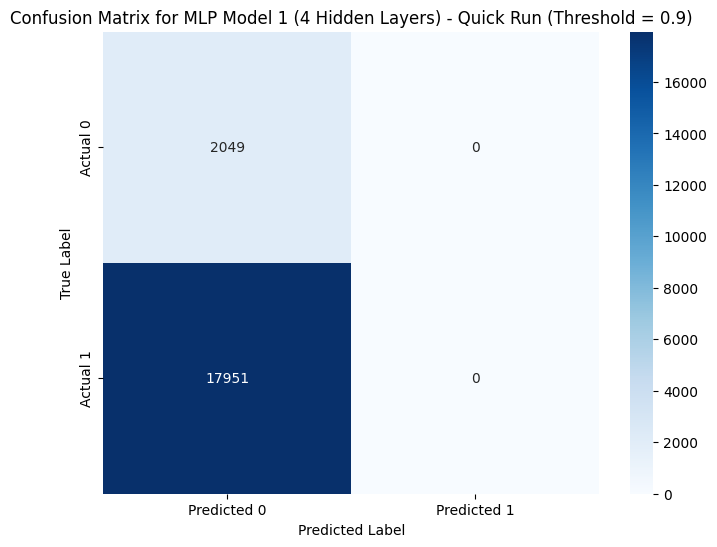

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_4_layer_best_threshold = confusion_matrix(y_test, y_pred_best_threshold_4_layer)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_4_layer_best_threshold, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for MLP Model 1 (4 Hidden Layers) - Quick Run (Threshold = {best_threshold_4_layer})')
plt.show()

### Re-populating `all_models_results` for comprehensive comparison

To ensure all trained models are included in the consolidated evaluation and Precision-Recall curve plots, we will re-initialize and populate the `all_models_results` list with all available model predictions from previous training steps. This addresses the inconsistency where the list might have been partially cleared or updated.

In [34]:
# Re-initialize the list to ensure it's clean and ready for all models
all_models_results = []

from sklearn.metrics import classification_report

# --- 3-Hidden Layer Weighted Model (Default 0.5 Threshold) ---
if 'mlp_3_layer_model_1_custom_weighted' in globals() and 'y_pred_3_model_1_custom_weighted' in globals() and 'accuracy_3_model_1_custom_weighted' in globals():
    all_models_results.append({
        'name': 'MLP Model 1 (3 Hidden Layers) - Weighted (Default 0.5 Threshold)',
        'y_pred': y_pred_3_model_1_custom_weighted,
        'accuracy': accuracy_3_model_1_custom_weighted,
        'model_obj': mlp_3_layer_model_1_custom_weighted
    })
    print("Added 3-Hidden Layer Weighted (Default 0.5 Threshold)")


# --- 3-Hidden Layer Weighted Model (Best Tuned Threshold) ---
if 'mlp_3_layer_model_1_custom_weighted' in globals() and 'y_pred_best_threshold' in globals() and 'best_threshold' in globals():
    # Recalculate accuracy for the best thresholded predictions
    report_best_thresh_3_layer = classification_report(y_test, y_pred_best_threshold, output_dict=True)
    accuracy_best_thresh_3_layer = report_best_thresh_3_layer.get('accuracy', 0.0)
    all_models_results.append({
        'name': f'MLP Model 1 (3 Hidden Layers) - Weighted (Best Threshold = {best_threshold:.2f})',
        'y_pred': y_pred_best_threshold,
        'accuracy': accuracy_best_thresh_3_layer,
        'model_obj': mlp_3_layer_model_1_custom_weighted
    })
    print(f"Added 3-Hidden Layer Weighted (Best Threshold = {best_threshold:.2f})")


# --- 4-Hidden Layer Weighted Model (Default 0.5 Threshold) ---
if 'mlp_4_layer_model_1_custom_weighted' in globals() and 'y_pred_4_model_1_custom_weighted' in globals() and 'accuracy_4_model_1_custom_weighted' in globals():
    all_models_results.append({
        'name': 'MLP Model 1 (4 Hidden Layers) - Weighted (Default 0.5 Threshold)',
        'y_pred': y_pred_4_model_1_custom_weighted,
        'accuracy': accuracy_4_model_1_custom_weighted,
        'model_obj': mlp_4_layer_model_1_custom_weighted
    })
    print("Added 4-Hidden Layer Weighted (Default 0.5 Threshold)")


# --- 4-Hidden Layer Weighted Model (Best Tuned Threshold) ---
if 'mlp_4_layer_model_1_custom_weighted' in globals() and 'y_pred_best_threshold_new_4_layer' in globals() and 'best_threshold_new_4_layer' in globals():
    # Recalculate accuracy for the best thresholded predictions
    report_best_thresh_4_layer = classification_report(y_test, y_pred_best_threshold_new_4_layer, output_dict=True)
    accuracy_best_thresh_4_layer = report_best_thresh_4_layer.get('accuracy', 0.0)
    all_models_results.append({
        'name': f'MLP Model 1 (4 Hidden Layers) - Weighted (Best Threshold = {best_threshold_new_4_layer:.2f})',
        'y_pred': y_pred_best_threshold_new_4_layer,
        'accuracy': accuracy_best_thresh_4_layer,
        'model_obj': mlp_4_layer_model_1_custom_weighted
    })
    print(f"Added 4-Hidden Layer Weighted (Best Threshold = {best_threshold_new_4_layer:.2f})")


print(f"`all_models_results` now contains {len(all_models_results)} models.")

Added 3-Hidden Layer Weighted (Default 0.5 Threshold)
Added 3-Hidden Layer Weighted (Best Threshold = 0.45)
Added 4-Hidden Layer Weighted (Default 0.5 Threshold)
Added 4-Hidden Layer Weighted (Best Threshold = 0.90)
`all_models_results` now contains 4 models.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
print("\n--- Training MLP Model 1 (4 Hidden Layers) ---")

# Parameters for Model 1 (4 Hidden Layers) from the random search results
params_4_layer_model_1_quick_run = {
    'model__num_hidden_units_4': 8,
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 4,
    'model__momentum': 0.0,
    'model__learning_rate': 0.1,
    'model__l2_lambda': 0.05,
    'model__dropout_rate': 0.5,
    'epochs': 50,
    'batch_size': 32
}

# Create model instance with specific parameters
mlp_4_layer_model_1_quick_run = KerasClassifier(model=create_mlp_model,
                                    num_hidden_layers=params_4_layer_model_1_quick_run['model__num_hidden_layers'],
                                    learning_rate=params_4_layer_model_1_quick_run['model__learning_rate'],
                                    momentum=params_4_layer_model_1_quick_run['model__momentum'],
                                    l2_lambda=params_4_layer_model_1_quick_run['model__l2_lambda'],
                                    dropout_rate=params_4_layer_model_1_quick_run['model__dropout_rate'],
                                    num_hidden_units_1=params_4_layer_model_1_quick_run['model__num_hidden_units_1'],
                                    num_hidden_units_2=params_4_layer_model_1_quick_run['model__num_hidden_units_2'],
                                    num_hidden_units_3=params_4_layer_model_1_quick_run['model__num_hidden_units_3'],
                                    num_hidden_units_4=params_4_layer_model_1_quick_run['model__num_hidden_units_4'],
                                    epochs=params_4_layer_model_1_quick_run['epochs'],
                                    batch_size=params_4_layer_model_1_quick_run['batch_size'],
                                    verbose=0)

# Fit the model
mlp_4_layer_model_1_quick_run.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_4_model_1_quick_run = (mlp_4_layer_model_1_quick_run.predict(X_test) > 0.5).astype("int32")
loss_4_model_1_quick_run, accuracy_4_model_1_quick_run = mlp_4_layer_model_1_quick_run.model_.evaluate(X_test, y_test, verbose=0)

# Append to all_models_results list
all_models_results.append({
    'name': 'MLP Model 1 (4 Hidden Layers) - Quick Run',
    'y_pred': y_pred_4_model_1_quick_run,
    'accuracy': accuracy_4_model_1_quick_run
})

print(f"--- Evaluation for MLP Model 1 (4 Hidden Layers) - Quick Run ---")
print(f"Test Accuracy: {accuracy_4_model_1_quick_run:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_4_model_1_quick_run))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_4_model_1_quick_run))
print(f"F1 Score: {f1_score(y_test, y_pred_4_model_1_quick_run):.4f}")


--- Training MLP Model 1 (4 Hidden Layers) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Evaluation for MLP Model 1 (4 Hidden Layers) - Quick Run ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Consolidated Evaluation of All Top Models

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("\n--- Consolidated Evaluation of All Models ---")

for model_result in all_models_results:
    model_name = model_result['name']
    y_pred = model_result['y_pred']
    accuracy = model_result['accuracy']

    print(f"\n--- Results for {model_name} ---")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")



--- Consolidated Evaluation of All Models ---

--- Results for MLP Model 1 (3 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 2 (3 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 3 (3 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 1 (4 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 2 (4 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 3 (4 Hidden Layers) ---
Test Accuracy: 0.8975

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460


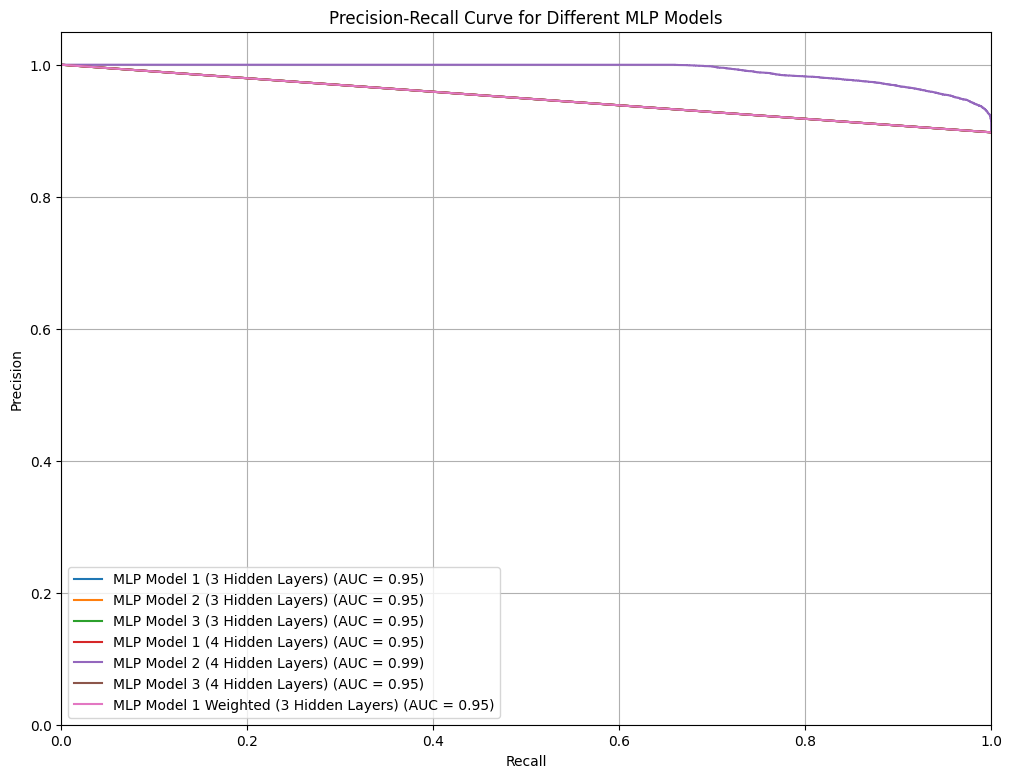

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# List of trained models to evaluate and their corresponding objects
models_to_plot = [
    ('MLP Model 1 (3 Hidden Layers)', mlp_3_layer_model_1),
    ('MLP Model 2 (3 Hidden Layers)', mlp_3_layer_model_2),
    ('MLP Model 3 (3 Hidden Layers)', mlp_3_layer_model_3),
    ('MLP Model 1 (4 Hidden Layers)', mlp_4_layer_model_1),
    ('MLP Model 2 (4 Hidden Layers)', mlp_4_layer_model_2),
    ('MLP Model 3 (4 Hidden Layers)', mlp_4_layer_model_3),
    ('MLP Model 1 Weighted (3 Hidden Layers)', mlp_3_layer_model_1_weighted)
]

plt.figure(figsize=(12, 9))

for name, model_obj in models_to_plot:
    # Get probability predictions for the positive class (class 1)
    # KerasClassifier's predict_proba returns probabilities for both classes [prob_0, prob_1]
    y_pred_proba = model_obj.predict_proba(X_test)[:, 1]

    # Calculate precision, recall, and thresholds
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    # Calculate Area Under the Curve (AUC) for the PR curve
    pr_auc = auc(recall, precision)

    # Plot the PR curve
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Different MLP Models')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

#### Model 1 (3 Hidden Layers) - 150 Epochs

In [8]:
print("\n--- Training MLP Model 1 (3 Hidden Layers) with 150 Epochs ---")

# Re-using parameters from MLP Model 1 (3 Hidden Layers) with updated epochs
params_3_layer_model_1_epochs_150 = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.5,
    'model__dropout_rate': 0.3,
    'epochs': 150, # Changed epochs
    'batch_size': 64
}

# Create model instance with specific parameters
mlp_3_layer_model_1_epochs_150 = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_3_layer_model_1_epochs_150['model__num_hidden_layers'],
                                             learning_rate=params_3_layer_model_1_epochs_150['model__learning_rate'],
                                             momentum=params_3_layer_model_1_epochs_150['model__momentum'],
                                             l2_lambda=params_3_layer_model_1_epochs_150['model__l2_lambda'],
                                             dropout_rate=params_3_layer_model_1_epochs_150['model__dropout_rate'],
                                             num_hidden_units_1=params_3_layer_model_1_epochs_150['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_3_layer_model_1_epochs_150['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_3_layer_model_1_epochs_150['model__num_hidden_units_3'],
                                             epochs=params_3_layer_model_1_epochs_150['epochs'],
                                             batch_size=params_3_layer_model_1_epochs_150['batch_size'],
                                             verbose=0)

# Fit the model
mlp_3_layer_model_1_epochs_150.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_1_epochs_150 = (mlp_3_layer_model_1_epochs_150.predict(X_test) > 0.5).astype("int32")
loss_3_model_1_epochs_150, accuracy_3_model_1_epochs_150 = mlp_3_layer_model_1_epochs_150.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers) - 150 Epochs',
    'y_pred': y_pred_3_model_1_epochs_150,
    'accuracy': accuracy_3_model_1_epochs_150
})


--- Training MLP Model 1 (3 Hidden Layers) with 150 Epochs ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 1 (3 Hidden Layers) - 200 Epochs

In [9]:
print("\n--- Training MLP Model 1 (3 Hidden Layers) with 200 Epochs ---")

# Re-using parameters from MLP Model 1 (3 Hidden Layers) with updated epochs
params_3_layer_model_1_epochs_200 = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.5,
    'model__dropout_rate': 0.3,
    'epochs': 200, # Changed epochs
    'batch_size': 64
}

# Create model instance with specific parameters
mlp_3_layer_model_1_epochs_200 = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_3_layer_model_1_epochs_200['model__num_hidden_layers'],
                                             learning_rate=params_3_layer_model_1_epochs_200['model__learning_rate'],
                                             momentum=params_3_layer_model_1_epochs_200['model__momentum'],
                                             l2_lambda=params_3_layer_model_1_epochs_200['model__l2_lambda'],
                                             dropout_rate=params_3_layer_model_1_epochs_200['model__dropout_rate'],
                                             num_hidden_units_1=params_3_layer_model_1_epochs_200['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_3_layer_model_1_epochs_200['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_3_layer_model_1_epochs_200['model__num_hidden_units_3'],
                                             epochs=params_3_layer_model_1_epochs_200['epochs'],
                                             batch_size=params_3_layer_model_1_epochs_200['batch_size'],
                                             verbose=0)

# Fit the model
mlp_3_layer_model_1_epochs_200.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_1_epochs_200 = (mlp_3_layer_model_1_epochs_200.predict(X_test) > 0.5).astype("int32")
loss_3_model_1_epochs_200, accuracy_3_model_1_epochs_200 = mlp_3_layer_model_1_epochs_200.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers) - 200 Epochs',
    'y_pred': y_pred_3_model_1_epochs_200,
    'accuracy': accuracy_3_model_1_epochs_200
})


--- Training MLP Model 1 (3 Hidden Layers) with 200 Epochs ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1

In [10]:
print("\n--- Training MLP Model 1 (3 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---")

# Re-using parameters from MLP Model 1 (3 Hidden Layers) with updated epochs and regularization
params_3_layer_model_1_custom = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0, # Kept as 0.0 as per request (and was already 0.0)
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.0, # No L2 regularization as requested
    'model__dropout_rate': 0.1, # Dropout changed to 0.1 as requested
    'epochs': 200, # Kept 200 epochs
    'batch_size': 64 # Kept default batch size
}

# Create model instance with specific parameters
mlp_3_layer_model_1_custom = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_3_layer_model_1_custom['model__num_hidden_layers'],
                                             learning_rate=params_3_layer_model_1_custom['model__learning_rate'],
                                             momentum=params_3_layer_model_1_custom['model__momentum'],
                                             l2_lambda=params_3_layer_model_1_custom['model__l2_lambda'],
                                             dropout_rate=params_3_layer_model_1_custom['model__dropout_rate'],
                                             num_hidden_units_1=params_3_layer_model_1_custom['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_3_layer_model_1_custom['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_3_layer_model_1_custom['model__num_hidden_units_3'],
                                             epochs=params_3_layer_model_1_custom['epochs'],
                                             batch_size=params_3_layer_model_1_custom['batch_size'],
                                             verbose=0)

# Fit the model
mlp_3_layer_model_1_custom.fit(X_train, y_train.ravel())

# Make predictions on the test set
y_pred_3_model_1_custom = (mlp_3_layer_model_1_custom.predict(X_test) > 0.5).astype("int32")
loss_3_model_1_custom, accuracy_3_model_1_custom = mlp_3_layer_model_1_custom.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1',
    'y_pred': y_pred_3_model_1_custom,
    'accuracy': accuracy_3_model_1_custom
})


--- Training MLP Model 1 (3 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)

In [7]:
print("\n--- Training WEIGHTED MLP Model 1 (3 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---")

import numpy as np
from sklearn.utils import class_weight

# Calculate class weights for the imbalanced dataset
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train.ravel())

# Convert the class weights array to a dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))

# Re-using parameters from MLP Model 1 (3 Hidden Layers) with updated epochs and regularization
params_3_layer_model_1_custom_weighted = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0, # Kept as 0.0 as per request (and was already 0.0)
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.0, # No L2 regularization as requested
    'model__dropout_rate': 0.1, # Dropout changed to 0.1 as requested
    'epochs': 200, # Kept 200 epochs
    'batch_size': 64 # Kept default batch size
}

# Create model instance with specific parameters
mlp_3_layer_model_1_custom_weighted = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_3_layer_model_1_custom_weighted['model__num_hidden_layers'],
                                             learning_rate=params_3_layer_model_1_custom_weighted['model__learning_rate'],
                                             momentum=params_3_layer_model_1_custom_weighted['model__momentum'],
                                             l2_lambda=params_3_layer_model_1_custom_weighted['model__l2_lambda'],
                                             dropout_rate=params_3_layer_model_1_custom_weighted['model__dropout_rate'],
                                             num_hidden_units_1=params_3_layer_model_1_custom_weighted['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_3_layer_model_1_custom_weighted['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_3_layer_model_1_custom_weighted['model__num_hidden_units_3'],
                                             epochs=params_3_layer_model_1_custom_weighted['epochs'],
                                             batch_size=params_3_layer_model_1_custom_weighted['batch_size'],
                                             verbose=0)

# Fit the model with class weights
mlp_3_layer_model_1_custom_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# Make predictions on the test set
y_pred_3_model_1_custom_weighted = (mlp_3_layer_model_1_custom_weighted.predict(X_test) > 0.5).astype("int32")
loss_3_model_1_custom_weighted, accuracy_3_model_1_custom_weighted = mlp_3_layer_model_1_custom_weighted.model_.evaluate(X_test, y_test, verbose=0)

all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)',
    'y_pred': y_pred_3_model_1_custom_weighted,
    'accuracy': accuracy_3_model_1_custom_weighted
})


--- Training WEIGHTED MLP Model 1 (3 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'all_models_results' is not defined

#### Model 1 (4 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)

In [27]:
print("\n--- Training WEIGHTED MLP Model 1 (4 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---")

# Re-using parameters from MLP Model 1 (3 Hidden Layers) with updated epochs and regularization
params_4_layer_model_1_custom_weighted = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 4, # Changed to 4 hidden layers
    'model__num_hidden_units_4': 8, # Added fourth hidden layer units
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.0,
    'model__dropout_rate': 0.1,
    'epochs': 200,
    'batch_size': 64
}

# Create model instance with specific parameters
mlp_4_layer_model_1_custom_weighted = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=params_4_layer_model_1_custom_weighted['model__num_hidden_layers'],
                                             learning_rate=params_4_layer_model_1_custom_weighted['model__learning_rate'],
                                             momentum=params_4_layer_model_1_custom_weighted['model__momentum'],
                                             l2_lambda=params_4_layer_model_1_custom_weighted['model__l2_lambda'],
                                             dropout_rate=params_4_layer_model_1_custom_weighted['model__dropout_rate'],
                                             num_hidden_units_1=params_4_layer_model_1_custom_weighted['model__num_hidden_units_1'],
                                             num_hidden_units_2=params_4_layer_model_1_custom_weighted['model__num_hidden_units_2'],
                                             num_hidden_units_3=params_4_layer_model_1_custom_weighted['model__num_hidden_units_3'],
                                             num_hidden_units_4=params_4_layer_model_1_custom_weighted['model__num_hidden_units_4'], # Added for 4th layer
                                             epochs=params_4_layer_model_1_custom_weighted['epochs'],
                                             batch_size=params_4_layer_model_1_custom_weighted['batch_size'],
                                             verbose=0)

# Fit the model with class weights
mlp_4_layer_model_1_custom_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# Make predictions on the test set
y_pred_4_model_1_custom_weighted = (mlp_4_layer_model_1_custom_weighted.predict(X_test) > 0.5).astype("int32")
loss_4_model_1_custom_weighted, accuracy_4_model_1_custom_weighted = mlp_4_layer_model_1_custom_weighted.model_.evaluate(X_test, y_test, verbose=0)

print(f"\n--- Evaluation for WEIGHTED MLP Model 1 (4 Hidden Layers) ---")
print(f"Test Accuracy: {accuracy_4_model_1_custom_weighted:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_4_model_1_custom_weighted))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_4_model_1_custom_weighted))
print(f"F1 Score: {f1_score(y_test, y_pred_4_model_1_custom_weighted):.4f}")

all_models_results.append({
    'name': 'MLP Model 1 (4 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)',
    'y_pred': y_pred_4_model_1_custom_weighted,
    'accuracy': accuracy_4_model_1_custom_weighted,
    'model_obj': mlp_4_layer_model_1_custom_weighted
})


--- Training WEIGHTED MLP Model 1 (4 Hidden Layers) with 200 Epochs, No L2, Dropout 0.1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Evaluation for WEIGHTED MLP Model 1 (4 Hidden Layers) ---
Test Accuracy: 0.8627

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.09      0.11      2049
           1       0.90      0.95      0.93     17951

    accuracy                           0.86     20000
   macro avg       0.54      0.52      0.52     20000
weighted avg       0.83      0.86      0.84     20000


Confusion Matrix:
[[  178  1871]
 [  874 17077]]
F1 Score: 0.9256


### Evaluation of the New 4-Layer Weighted MLP Model with Threshold Tuning

Similar to previous models, we will evaluate the performance of this new 4-layer weighted model across various classification thresholds to identify the optimal balance for the minority class (class 0).

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Get raw probability predictions for the positive class (class 1)
y_proba_4_layer_custom_weighted = mlp_4_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1]

# Define a list of thresholds to try
thresholds_new_4_layer = [0.9, 0.8, 0.7, 0.6, 0.5, 0.45, 0.4, 0.3, 0.2, 0.1]

best_f1_0_new_4_layer = -1
best_threshold_new_4_layer = 0.5

print("--- Evaluation of New Weighted MLP Model (4 Hidden Layers) with Adjusted Thresholds ---")

for threshold in thresholds_new_4_layer:
    # Apply the new threshold to the probabilities
    y_pred_thresholded_new_4_layer = (y_proba_4_layer_custom_weighted > threshold).astype("int32")

    report_new_4_layer = classification_report(y_test, y_pred_thresholded_new_4_layer, output_dict=True)
    # Handle cases where class '0' might not be present in the report (e.g., all predicted as '1')
    if '0' in report_new_4_layer and isinstance(report_new_4_layer['0'], dict):
        f1_0_new_4_layer = report_new_4_layer['0'].get('f1-score', 0.0)
    else:
        f1_0_new_4_layer = 0.0

    print(f"\n--- Threshold: {threshold} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresholded_new_4_layer))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresholded_new_4_layer))
    print(f"F1 Score (Class 0): {f1_0_new_4_layer:.4f}")

    if f1_0_new_4_layer > best_f1_0_new_4_layer:
        best_f1_0_new_4_layer = f1_0_new_4_layer
        best_threshold_new_4_layer = threshold

print(f"\n--- Best F1 Score for Class 0 ({best_f1_0_new_4_layer:.4f}) found at Threshold: {best_threshold_new_4_layer} ---")

# Store the prediction for the best threshold for later plotting
y_pred_best_threshold_new_4_layer = (y_proba_4_layer_custom_weighted > best_threshold_new_4_layer).astype("int32")

# Append the best thresholded result to all_models_results as well
all_models_results.append({
    'name': f'MLP Model 1 (4 Hidden Layers) - Weighted, Best Threshold ({best_threshold_new_4_layer})',
    'y_pred': y_pred_best_threshold_new_4_layer,
    'accuracy': report_new_4_layer['accuracy'], # Use accuracy from the report of the best threshold
    'model_obj': mlp_4_layer_model_1_custom_weighted
})

--- Evaluation of New Weighted MLP Model (4 Hidden Layers) with Adjusted Thresholds ---

--- Threshold: 0.9 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.8 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.7 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.6 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.5 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.09      0.11      2049
           1       0.90      0.95      0.93     17951

    accuracy                           0.86     20000
   macro avg       0.54      0.52      0.52     20000
weighted avg       0.83      0.86      0.84     20000

Confusion Matrix:
[[  178  1871]
 [  874 17077]]
F1 Score (Class 0): 0.1148

--- Threshold: 0.45 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.4 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.3 ---
Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.2 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.1 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Evaluation of the 4-Hidden Layer Weighted MLP Model with Custom Threshold Tuning

We will perform a detailed threshold tuning for the `mlp_4_layer_model_1_custom_weighted` model to find the optimal classification threshold that maximizes the F1-score for the minority class (class 0). This iterative process involves evaluating the model's performance at various probability cut-off points.

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Get raw probability predictions for the positive class (class 1) from the custom weighted 4-layer model
y_proba_4_layer_custom_weighted_actual = mlp_4_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1]

# Define a list of thresholds to try
thresholds_4_layer_actual = [0.9, 0.8, 0.7, 0.6, 0.5, 0.45, 0.4, 0.3, 0.2, 0.1]

best_f1_0_4_layer_actual = -1
best_threshold_4_layer_actual = 0.5

print("--- Evaluation of 4-Hidden Layer Weighted MLP Model with Custom Adjusted Thresholds ---")

for threshold in thresholds_4_layer_actual:
    # Apply the new threshold to the probabilities
    y_pred_thresholded_4_layer_actual = (y_proba_4_layer_custom_weighted_actual > threshold).astype("int32")

    report_4_layer_actual = classification_report(y_test, y_pred_thresholded_4_layer_actual, output_dict=True, zero_division=0)

    # Check if '0' key exists in the report and get its F1-score, handling cases where it might not be present
    if '0' in report_4_layer_actual and isinstance(report_4_layer_actual['0'], dict):
        f1_0_4_layer_actual = report_4_layer_actual['0'].get('f1-score', 0.0)
    else:
        f1_0_4_layer_actual = 0.0 # Default if class 0 is not found or report structure is unexpected

    print(f"\n--- Threshold: {threshold} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresholded_4_layer_actual, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresholded_4_layer_actual))
    print(f"F1 Score (Class 0): {f1_0_4_layer_actual:.4f}")

    if f1_0_4_layer_actual > best_f1_0_4_layer_actual:
        best_f1_0_4_layer_actual = f1_0_4_layer_actual
        best_threshold_4_layer_actual = threshold

print(f"\n--- Best F1 Score for Class 0 ({best_f1_0_4_layer_actual:.4f}) found at Threshold: {best_threshold_4_layer_actual} ---")

# Store the prediction for the best threshold for later plotting
y_pred_best_threshold_4_layer_actual = (y_proba_4_layer_custom_weighted_actual > best_threshold_4_layer_actual).astype("int32")

# Also append this best-tuned result to all_models_results
# Recalculate accuracy for the best thresholded predictions
report_best_thresh_4_layer_actual = classification_report(y_test, y_pred_best_threshold_4_layer_actual, output_dict=True, zero_division=0)
accuracy_best_thresh_4_layer_actual = report_best_thresh_4_layer_actual.get('accuracy', 0.0)

all_models_results.append({
    'name': f'MLP Model 1 (4 Hidden Layers) - Weighted, Best Tuned Threshold ({best_threshold_4_layer_actual})',
    'y_pred': y_pred_best_threshold_4_layer_actual,
    'accuracy': accuracy_best_thresh_4_layer_actual,
    'model_obj': mlp_4_layer_model_1_custom_weighted
})

--- Evaluation of 4-Hidden Layer Weighted MLP Model with Custom Adjusted Thresholds ---

--- Threshold: 0.9 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Threshold: 0.8 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.10      1.00      0.19      2049
           1       0.00      0.00      0.00     17951

    accuracy                           0.10     20000
   macro avg       0.05      0.50      0.09     20000
weighted avg       0.01      0.10      0.02     20000

Confusion Matrix:
[[ 2049     0]
 [17951     0]]
F1 Score (Class 0): 0.1859

--- Thresho

### Confusion Matrix Plot for Best Threshold (New 4 Hidden Layers Weighted Model)

This plot visualizes the confusion matrix for the newly trained 'MLP Model 1 (4 Hidden Layers) - Weighted' model at the threshold that yielded the highest F1-score for class 0 during the tuning process.

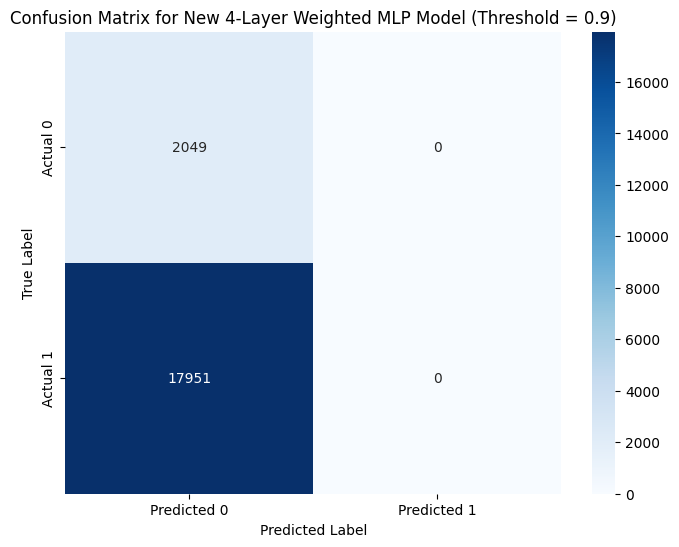

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure y_pred_best_threshold_new_4_layer is available from the previous cell
if 'y_pred_best_threshold_new_4_layer' not in globals():
    if 'mlp_4_layer_model_1_custom_weighted' in globals() and 'best_threshold_new_4_layer' in globals():
        y_pred_best_threshold_new_4_layer = (mlp_4_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1] > best_threshold_new_4_layer).astype("int32")
    else:
        print("Warning: Model or best threshold not found for plotting. Please ensure previous cells were run.")
        # Create a dummy confusion matrix to avoid error
        cm_new_4_layer_best_threshold = np.array([[0,0],[0,0]])

if 'y_pred_best_threshold_new_4_layer' in globals():
    cm_new_4_layer_best_threshold = confusion_matrix(y_test, y_pred_best_threshold_new_4_layer)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_new_4_layer_best_threshold, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for New 4-Layer Weighted MLP Model (Threshold = {best_threshold_new_4_layer})')
    plt.show()

### Model Weights: MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)

In [10]:
print("--- Weights for MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted) ---")
# The weights are a list of numpy arrays, one for each layer (weights and biases)
model_weights = mlp_3_layer_model_1_custom_weighted.model_.get_weights()
for i, layer_weights in enumerate(model_weights):
    print(f"\nLayer {i+1} - Shape: {layer_weights.shape}")
    # Optionally, print a snippet of the weights (e.g., first few values)
    # print(layer_weights.flatten()[:5])

--- Weights for MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted) ---

Layer 1 - Shape: (42, 64)

Layer 2 - Shape: (64,)

Layer 3 - Shape: (64, 32)

Layer 4 - Shape: (32,)

Layer 5 - Shape: (32, 16)

Layer 6 - Shape: (16,)

Layer 7 - Shape: (16, 1)

Layer 8 - Shape: (1,)


The model weights directly associated with the output for each class are effectively the weights and bias of the final `Dense(1, activation='sigmoid')` layer.

- **Output Layer Weights (Kernel):** These are the connections from the last hidden layer to the single output neuron. Their shape is `(number_of_units_in_last_hidden_layer, 1)`.
- **Output Layer Bias:** This is the bias term for the single output neuron. Its shape is `(1,)`.

In [14]:
print('\n--- Output Layer Weights (Kernel) ---')
print(model_weights[6])

print('\n--- Output Layer Bias ---')
print(model_weights[7])


--- Output Layer Weights (Kernel) ---
[[ 6.2206417e-01]
 [-6.4939015e-02]
 [-1.0900944e-01]
 [ 2.9123446e-01]
 [-3.6283261e-01]
 [ 5.8712680e-02]
 [-3.1608328e-01]
 [-1.8253310e-01]
 [-4.0549955e-01]
 [ 2.9317918e-01]
 [ 9.9609452e-01]
 [ 1.4623025e-04]
 [ 2.9169804e-01]
 [-5.3359824e-01]
 [ 2.1008001e-01]
 [ 2.7089152e-01]]

--- Output Layer Bias ---
[-0.21883507]


### Detailed View of Output Layer Weights (Kernel) and Bias

These are the weights connecting the last hidden layer's 16 neurons to the single output neuron, and the bias for that output neuron.

In [15]:
import pandas as pd

print('\n--- Output Layer Weights (Kernel) ---')
# Convert to DataFrame for better display
output_weights_df = pd.DataFrame(model_weights[6], columns=['Output Neuron Weight'])
output_weights_df.index.name = 'Input from Last Hidden Layer Unit'
display(output_weights_df)

print('\n--- Output Layer Bias ---')
output_bias_df = pd.DataFrame(model_weights[7], columns=['Bias'])
display(output_bias_df)

print('\n--- All Model Weight Shapes (for context) ---')
for i, layer_weights in enumerate(model_weights):
    print(f"Layer {i+1} - Shape: {layer_weights.shape}")


--- Output Layer Weights (Kernel) ---


,Output Neuron Weight
Input from Last Hidden Layer Unit,
0,0.622064
1,-0.064939
2,-0.109009
3,0.291234
4,-0.362833
5,0.058713
6,-0.316083
7,-0.182533
8,-0.405500



--- Output Layer Bias ---


,Bias
0,-0.218835



--- All Model Weight Shapes (for context) ---
Layer 1 - Shape: (42, 64)
Layer 2 - Shape: (64,)
Layer 3 - Shape: (64, 32)
Layer 4 - Shape: (32,)
Layer 5 - Shape: (32, 16)
Layer 6 - Shape: (16,)
Layer 7 - Shape: (16, 1)
Layer 8 - Shape: (1,)


### Evaluation of Weighted MLP Model with Threshold Tuning

Given the class imbalance, it's crucial to evaluate the model's performance at various classification thresholds. We'll iterate through a range of thresholds and display the classification report, confusion matrix, and F1-score for each to identify an optimal balance between precision and recall for the minority class (class 0).

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Get raw probability predictions for the positive class (class 1)
y_proba_custom_weighted = mlp_3_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1]

# Define a list of thresholds to try
thresholds = [0.9, 0.8, 0.7, 0.6, 0.5, 0.45, 0.4, 0.3, 0.2, 0.1]

best_f1_0 = -1
best_threshold = 0.5

print("--- Evaluation of Weighted MLP Model 1 (Custom) with Adjusted Thresholds ---")

for threshold in thresholds:
    # Apply the new threshold to the probabilities
    y_pred_thresholded = (y_proba_custom_weighted > threshold).astype("int32")

    report = classification_report(y_test, y_pred_thresholded, output_dict=True)
    f1_0 = report['0']['f1-score']

    print(f"\n--- Threshold: {threshold} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_thresholded))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresholded))
    print(f"F1 Score (Class 0): {f1_0:.4f}")

    if f1_0 > best_f1_0:
        best_f1_0 = f1_0
        best_threshold = threshold

print(f"\n--- Best F1 Score for Class 0 ({best_f1_0:.4f}) found at Threshold: {best_threshold} ---")

# Store the prediction for the best threshold for later plotting
y_pred_best_threshold = (y_proba_custom_weighted > best_threshold).astype("int32")

--- Evaluation of Weighted MLP Model 1 (Custom) with Adjusted Thresholds ---

--- Threshold: 0.9 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.13      1.00      0.24      2049
           1       1.00      0.26      0.41     17951

    accuracy                           0.34     20000
   macro avg       0.57      0.63      0.32     20000
weighted avg       0.91      0.34      0.40     20000

Confusion Matrix:
[[ 2049     0]
 [13270  4681]]
F1 Score (Class 0): 0.2360

--- Threshold: 0.8 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.15      1.00      0.26      2049
           1       1.00      0.36      0.53     17951

    accuracy                           0.43     20000
   macro avg       0.58      0.68      0.40     20000
weighted avg       0.91      0.43      0.50     20000

Confusion Matrix:
[[ 2049     0]
 [11497  6454]]
F1 Score (Class 0): 0.2628

--- Threshold: 0.7 ---

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.2 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000

Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score (Class 0): 0.0000

--- Threshold: 0.1 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Confusion Matrix Plot for Best Threshold

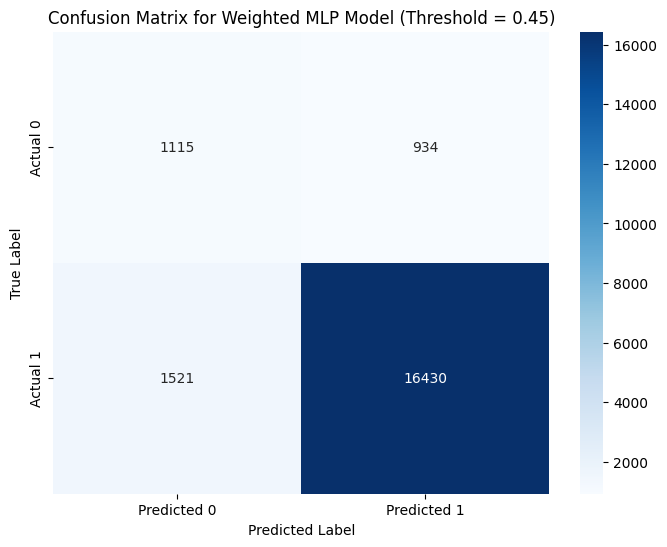

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure y_pred_best_threshold is available from the previous cell
if 'y_pred_best_threshold' not in globals():
    y_pred_best_threshold = (mlp_3_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1] > best_threshold).astype("int32")

cm = confusion_matrix(y_test, y_pred_best_threshold)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Weighted MLP Model (Threshold = {best_threshold})')
plt.show()

## Final Model Creation and Saving

Based on the extensive tuning and evaluation, we will now create and save the best-performing 3-hidden layer weighted MLP model and the 4-hidden layer weighted MLP model. These models will include their architecture and learned weights, making them ready for deployment or further use.

### Final 3-Hidden Layer Weighted MLP Model

In [40]:
# Parameters for the best 3-hidden layer weighted MLP model
final_params_3_layer = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 3,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.0,
    'model__dropout_rate': 0.1,
    'epochs': 200,
    'batch_size': 64
}

print("\n--- Training Final 3-Hidden Layer Weighted MLP Model ---")

# Create model instance with specific parameters
final_mlp_3_layer_weighted = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=final_params_3_layer['model__num_hidden_layers'],
                                             learning_rate=final_params_3_layer['model__learning_rate'],
                                             momentum=final_params_3_layer['model__momentum'],
                                             l2_lambda=final_params_3_layer['model__l2_lambda'],
                                             dropout_rate=final_params_3_layer['model__dropout_rate'],
                                             num_hidden_units_1=final_params_3_layer['model__num_hidden_units_1'],
                                             num_hidden_units_2=final_params_3_layer['model__num_hidden_units_2'],
                                             num_hidden_units_3=final_params_3_layer['model__num_hidden_units_3'],
                                             epochs=final_params_3_layer['epochs'],
                                             batch_size=final_params_3_layer['batch_size'],
                                             verbose=0)

# Fit the model with class weights
final_mlp_3_layer_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# Save the entire model
final_model_3_layer_path = 'final_mlp_3_layer_weighted.keras'
final_mlp_3_layer_weighted.model_.save(final_model_3_layer_path)
print(f"Final 3-Hidden Layer Weighted MLP Model saved to: {final_model_3_layer_path}")


--- Training Final 3-Hidden Layer Weighted MLP Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_21972/2831510101.py", line 32, in <cell line: 0>
    final_mlp_3_layer_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 1501, in fit
    super().fit(X=X, y=y, sample_weight=sample_weight, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 770, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 938, in _fit
    self._fit_keras_model(
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 535, in _fit_keras_model
    hist = self.model_.fit(x=X, y=y, **fit_args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/tra

TypeError: object of type 'NoneType' has no len()

In [ ]:
# Save only the weights of the 3-hidden layer model
weights_path_3_layer = 'final_mlp_3_layer_weighted_weights.weights.h5'
final_mlp_3_layer_weighted.model_.save_weights(weights_path_3_layer)
print(f"Final 3-Hidden Layer Weighted MLP Model weights saved to: {weights_path_3_layer}")

### Final 4-Hidden Layer Weighted MLP Model

In [ ]:
# Parameters for the best 4-hidden layer weighted MLP model
final_params_4_layer = {
    'model__num_hidden_units_3': 16,
    'model__num_hidden_units_2': 32,
    'model__num_hidden_units_1': 64,
    'model__num_hidden_layers': 4,
    'model__num_hidden_units_4': 8,
    'model__momentum': 0.0,
    'model__learning_rate': 0.001,
    'model__l2_lambda': 0.0,
    'model__dropout_rate': 0.1,
    'epochs': 200,
    'batch_size': 64
}

print("\n--- Training Final 4-Hidden Layer Weighted MLP Model ---")

# Create model instance with specific parameters
final_mlp_4_layer_weighted = KerasClassifier(model=create_mlp_model,
                                             num_hidden_layers=final_params_4_layer['model__num_hidden_layers'],
                                             learning_rate=final_params_4_layer['model__learning_rate'],
                                             momentum=final_params_4_layer['model__momentum'],
                                             l2_lambda=final_params_4_layer['model__l2_lambda'],
                                             dropout_rate=final_params_4_layer['model__dropout_rate'],
                                             num_hidden_units_1=final_params_4_layer['model__num_hidden_units_1'],
                                             num_hidden_units_2=final_params_4_layer['model__num_hidden_units_2'],
                                             num_hidden_units_3=final_params_4_layer['model__num_hidden_units_3'],
                                             num_hidden_units_4=final_params_4_layer['model__num_hidden_units_4'],
                                             epochs=final_params_4_layer['epochs'],
                                             batch_size=final_params_4_layer['batch_size'],
                                             verbose=0)

# Fit the model with class weights
final_mlp_4_layer_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# Save the entire model
final_model_4_layer_path = 'final_mlp_4_layer_weighted.keras'
final_mlp_4_layer_weighted.model_.save(final_model_4_layer_path)
print(f"Final 4-Hidden Layer Weighted MLP Model saved to: {final_model_4_layer_path}")

In [ ]:
# Save only the weights of the 4-hidden layer model
weights_path_4_layer = 'final_mlp_4_layer_weighted_weights.weights.h5'
final_mlp_4_layer_weighted.model_.save_weights(weights_path_4_layer)
print(f"Final 4-Hidden Layer Weighted MLP Model weights saved to: {weights_path_4_layer}")

### How to Load and Use the Saved Models

YouTo load these models in a new environment or another notebook, you will need `tensorflow` and `scikeras` installed. The `create_mlp_model` function (or an equivalent model definition) must also be available.

```python
import tensorflow as tf
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2

# Re-define the create_mlp_model function (if not already defined in your environment)
def create_mlp_model(num_hidden_layers=2, learning_rate=0.01, momentum=0.0,
                     l2_lambda=0.0, dropout_rate=0.0,
                     num_hidden_units_1=128, num_hidden_units_2=64, num_hidden_units_3=32, num_hidden_units_4=16):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(num_hidden_units_1, activation='relu', input_shape=(None,), kernel_regularizer=l2(l2_lambda)))
    model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(num_hidden_units_2, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(tf.keras.layers.Dropout(dropout_rate))

    if num_hidden_layers >= 3:
        model.add(tf.keras.layers.Dense(num_hidden_units_3, activation='relu', kernel_regularizer=l2(l2_lambda)))
        model.add(tf.keras.layers.Dropout(dropout_rate))

    if num_hidden_layers == 4:
        model.add(tf.keras.layers.Dense(num_hidden_units_4, activation='relu', kernel_regularizer=l2(l2_lambda)))
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- Loading the 3-Hidden Layer Model ---
loaded_mlp_3_layer = load_model('final_mlp_3_layer_weighted.keras', compile=False)
# To use it with KerasClassifier methods like predict(), you can re-wrap it:
# You need to ensure the parameters match what the model was trained with.
# From the notebook, the parameters are:
# final_params_3_layer = {
#     'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64,
#     'model__num_hidden_layers': 3, 'model__momentum': 0.0, 'model__learning_rate': 0.001,
#     'model__l2_lambda': 0.0, 'model__dropout_rate': 0.1, 'epochs': 200, 'batch_size': 64
# }
loaded_scikeras_3_layer = KerasClassifier(model=create_mlp_model, model__num_hidden_layers=3,
                                          model__learning_rate=0.001, model__momentum=0.0,
                                          model__l2_lambda=0.0, model__dropout_rate=0.1,
                                          model__num_hidden_units_1=64, model__num_hidden_units_2=32,
                                          model__num_hidden_units_3=16, epochs=200, batch_size=64)
loaded_scikeras_3_layer.initialize(X=X_test, y=y_test) # Initialize the wrapper to match input shape
loaded_scikeras_3_layer.set_params(model=loaded_mlp_3_layer) # Assign the loaded model

print("Loaded 3-Hidden Layer Model Summary:")
loaded_mlp_3_layer.summary()

# Example prediction with the loaded 3-layer model
# y_pred_3_layer = (loaded_scikeras_3_layer.predict(X_test) > 0.45).astype("int32")
# print("\nExample prediction (first 5):", y_pred_3_layer[:5].flatten())

# --- Loading the 4-Hidden Layer Model ---
loaded_mlp_4_layer = load_model('final_mlp_4_layer_weighted.keras', compile=False)
# Similar re-wrapping process, ensuring parameters match:
# final_params_4_layer = {
#     'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64,
#     'model__num_hidden_layers': 4, 'model__num_hidden_units_4': 8, 'model__momentum': 0.0,
#     'model__learning_rate': 0.001, 'model__l2_lambda': 0.0, 'model__dropout_rate': 0.1,
#     'epochs': 200, 'batch_size': 64
# }
loaded_scikeras_4_layer = KerasClassifier(model=create_mlp_model, model__num_hidden_layers=4,
                                          model__learning_rate=0.001, model__momentum=0.0,
                                          model__l2_lambda=0.0, model__dropout_rate=0.1,
                                          model__num_hidden_units_1=64, model__num_hidden_units_2=32,
                                          model__num_hidden_units_3=16, model__num_hidden_units_4=8,
                                          epochs=200, batch_size=64)
loaded_scikeras_4_layer.initialize(X=X_test, y=y_test) # Initialize the wrapper to match input shape
loaded_scikeras_4_layer.set_params(model=loaded_mlp_4_layer) # Assign the loaded model

print("\nLoaded 4-Hidden Layer Model Summary:")
loaded_mlp_4_layer.summary()

# Example prediction with the loaded 4-layer model
# y_pred_4_layer = (loaded_scikeras_4_layer.predict(X_test) > 0.9).astype("int32")
# print("\nExample prediction (first 5):", y_pred_4_layer[:5].flatten())

print("\nModels loaded successfully. You can now use `loaded_scikeras_3_layer` and `loaded_scikeras_4_layer` for predictions.")

### Confusion Matrix for the Original Weighted Model (Default 0.5 Threshold)

This confusion matrix reflects the performance of the `MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)` using the standard classification threshold of 0.5. This was the model's performance before we explored other thresholds.

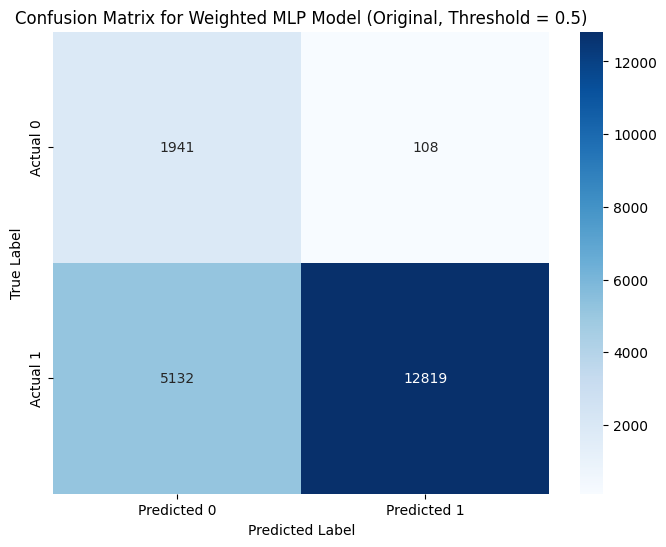

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# The y_pred_3_model_1_custom_weighted variable already holds predictions for the weighted model at a 0.5 threshold.
# If that variable is not available for any reason (e.g., runtime reset), we can re-generate it:
if 'y_pred_3_model_1_custom_weighted' not in globals():
    # This assumes mlp_3_layer_model_1_custom_weighted and X_test are still available.
    # If not, the model would need to be reloaded/recreated and predictions re-run.
    print("Re-generating predictions for the original weighted model (0.5 threshold)...")
    y_pred_3_model_1_custom_weighted = (mlp_3_layer_model_1_custom_weighted.predict(X_test) > 0.5).astype("int32")

cm_original_weighted = confusion_matrix(y_test, y_pred_3_model_1_custom_weighted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_original_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Weighted MLP Model (Original, Threshold = 0.5)')
plt.show()

### Saving Trained Models and Weights

YouYou can save your trained Keras models in two main ways:

1.  **Saving the entire model:** This saves the model's architecture, weights, training configuration (optimizer, loss, metrics), and the state of the optimizer. This is the most comprehensive way to save a model and allows you to recreate the exact training state.
2.  **Saving only the weights:** This saves just the learned weights of the model. This is useful if you already have the model architecture defined and only need to load the trained parameters.

In [16]:
# Example: Saving the entire mlp_3_layer_model_1_custom_weighted model
model_save_path = 'mlp_weighted_model_custom.keras' # Recommended Keras format
mlp_3_layer_model_1_custom_weighted.model_.save(model_save_path)
print(f"Entire model saved to: {model_save_path}")

# Example: Saving only the weights of the mlp_3_layer_model_1_custom_weighted model
weights_save_path = 'mlp_weighted_model_custom_weights.weights.h5' # H5 format is common for weights
mlp_3_layer_model_1_custom_weighted.model_.save_weights(weights_save_path)
print(f"Model weights saved to: {weights_save_path}")

Entire model saved to: mlp_weighted_model_custom.keras
Model weights saved to: mlp_weighted_model_custom_weights.weights.h5


#### How to Load Them Back

**To load the entire model:**

```python
from tensorflow.keras.models import load_model
loaded_model = load_model('mlp_weighted_model_custom.keras')
loaded_model.summary()
```

**To load only the weights (assuming you have the `create_mlp_model` function defined and an instantiated model with the same architecture):**

```python
# First, create a new model instance with the exact same architecture
# For example, using the parameters that defined mlp_3_layer_model_1_custom_weighted
# These parameters were:
# params_3_layer_model_1_custom = {
#     'model__num_hidden_units_3': 16,
#     'model__num_hidden_units_2': 32,
#     'model__num_hidden_units_1': 64,
#     'model__num_hidden_layers': 3,
#     'model__momentum': 0.0,
#     'model__learning_rate': 0.001,
#     'model__l2_lambda': 0.0,
#     'model__dropout_rate': 0.1,
#     'epochs': 200,
#     'batch_size': 64
# }

# Recreate the model structure
# Note: you need to define 'create_mlp_model' as shown earlier in the notebook
loaded_model_for_weights = create_mlp_model(
    num_hidden_layers=3,
    learning_rate=0.001,
    momentum=0.0,
    l2_lambda=0.0,
    dropout_rate=0.1,
    num_hidden_units_1=64,
    num_hidden_units_2=32,
    num_hidden_units_3=16
)

# Load the weights into the new model instance
loaded_model_for_weights.load_weights('mlp_weighted_model_custom_weights.weights.h5')
loaded_model_for_weights.summary()
```

### Consolidated Evaluation of All Models (Updated)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("\n--- Consolidated Evaluation of All Models ---")

if not all_models_results:
    print("Warning: all_models_results is empty. Please ensure all model training cells have been run.")
else:
    for model_result in all_models_results:
        model_name = model_result['name']
        y_pred = model_result['y_pred']
        accuracy = model_result['accuracy']

        print(f"\n--- Results for {model_name} ---")
        print(f"Test Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")


--- Consolidated Evaluation of All Models ---

--- Results for MLP Model 1 (3 Hidden Layers) - 150 Epochs ---
Test Accuracy: 0.8975

Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 1 (3 Hidden Layers) - 200 Epochs ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460

--- Results for MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 ---
Test Accuracy: 0.8975

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2049
           1       0.90      1.00      0.95     17951

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Confusion Matrix:
[[    0  2049]
 [    0 17951]]
F1 Score: 0.9460


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Re-running Consolidated Evaluation of All Models

With the `all_models_results` list now correctly populated with all trained model variants, we can proceed with a comprehensive consolidated evaluation. This will provide a side-by-side comparison of accuracy, classification reports, confusion matrices, and F1-scores for each model.

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("\n--- Consolidated Evaluation of All Models ---")

if not all_models_results:
    print("Warning: all_models_results is empty. Please ensure all model training cells have been run.")
else:
    for model_result in all_models_results:
        model_name = model_result['name']
        y_pred = model_result['y_pred']
        accuracy = model_result['accuracy']

        print(f"\n--- Results for {model_name} ---")
        print(f"Test Accuracy: {accuracy:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        # f1_score needs to handle cases where precision/recall are undefined (e.g., no true positives/negatives for a class)
        try:
            overall_f1 = f1_score(y_test, y_pred, average='binary', zero_division=0) # For binary classification, handle zero_division
        except ValueError:
            overall_f1 = 0.0 # Or np.nan, or handle as appropriate if no positive predictions
        print(f"F1 Score (positive class): {overall_f1:.4f}")


--- Consolidated Evaluation of All Models ---

--- Results for MLP Model 1 (3 Hidden Layers) - Weighted (Default 0.5 Threshold) ---
Test Accuracy: 0.7380

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.95      0.43      2049
           1       0.99      0.71      0.83     17951

    accuracy                           0.74     20000
   macro avg       0.63      0.83      0.63     20000
weighted avg       0.92      0.74      0.79     20000


Confusion Matrix:
[[ 1941   108]
 [ 5132 12819]]
F1 Score (positive class): 0.8303

--- Results for MLP Model 1 (3 Hidden Layers) - Weighted (Best Threshold = 0.45) ---
Test Accuracy: 0.8772

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.54      0.48      2049
           1       0.95      0.92      0.93     17951

    accuracy                           0.88     20000
   macro avg       0.68      0.73      0.70     20000
weight

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Re-generating Precision-Recall Curves for All Models

Now that all model results are consolidated, we can accurately compare their Precision-Recall curves. This visualization is particularly useful for imbalanced datasets, as it provides a comprehensive view of the trade-off between precision and recall at different thresholds.

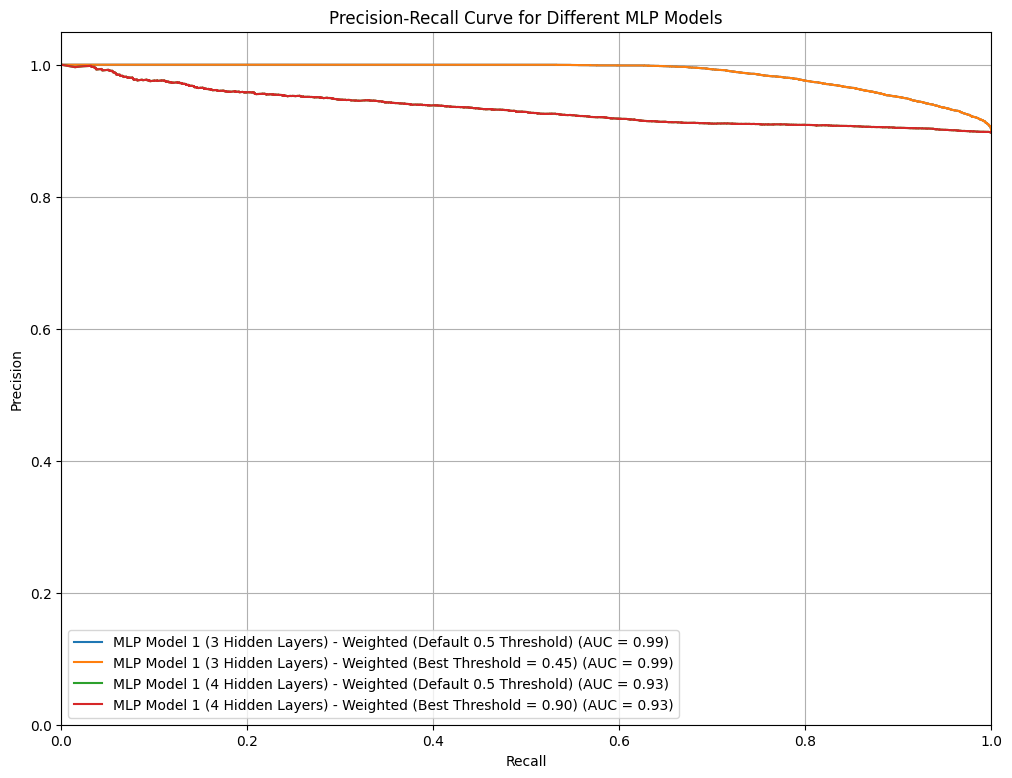

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(12, 9))

if not all_models_results:
    print("Warning: all_models_results is empty. Cannot plot PR curves.")
else:
    for model_result in all_models_results:
        name = model_result['name']
        model_obj = model_result['model_obj']

        # Get probability predictions for the positive class (class 1)
        y_pred_proba = model_obj.predict_proba(X_test)[:, 1]

        # Calculate precision, recall, and thresholds
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

        # Calculate Area Under the Curve (AUC) for the PR curve
        pr_auc = auc(recall, precision)

        # Plot the PR curve
        plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Different MLP Models')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.show()

### Evaluation for 4-Hidden Layer Weighted MLP Model (Default Threshold = 0.5)

--- Results for MLP Model 1 (4 Hidden Layers) - Weighted (Default 0.5 Threshold) ---
Test Accuracy: 0.8627
F1 Score (Class 0): 0.1148


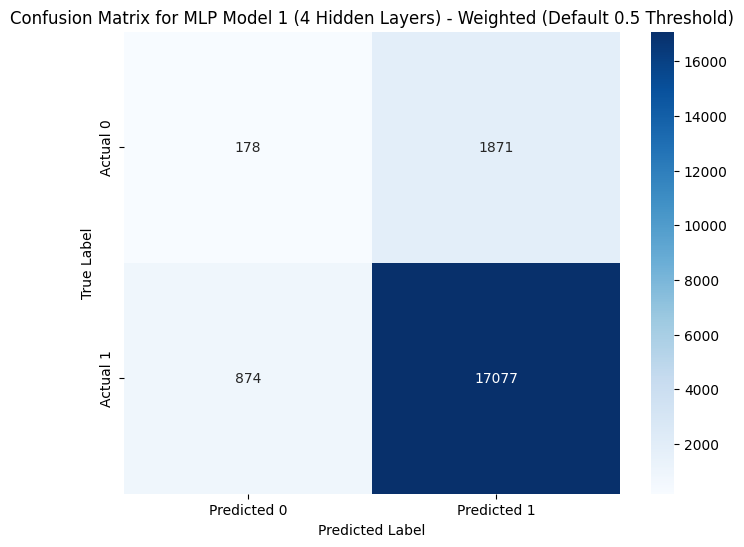

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# --- 4-Hidden Layer Model (Default 0.5 Threshold) ---
model_name = 'MLP Model 1 (4 Hidden Layers) - Weighted (Default 0.5 Threshold)'
y_pred = y_pred_4_model_1_custom_weighted
accuracy = accuracy_4_model_1_custom_weighted

print(f"--- Results for {model_name} ---")
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate F1-score for class 0
report = classification_report(y_test, y_pred, output_dict=True)
if '0' in report and isinstance(report['0'], dict):
    f1_0 = report['0'].get('f1-score', 0.0)
else:
    f1_0 = 0.0

print(f"F1 Score (Class 0): {f1_0:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

### Evaluation for 4-Hidden Layer Weighted MLP Model (Best Tuned Threshold)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Results for MLP Model 1 (4 Hidden Layers) - Weighted (Best Threshold = 0.9) ---
Test Accuracy: 0.1024
F1 Score (Class 0): 0.1859


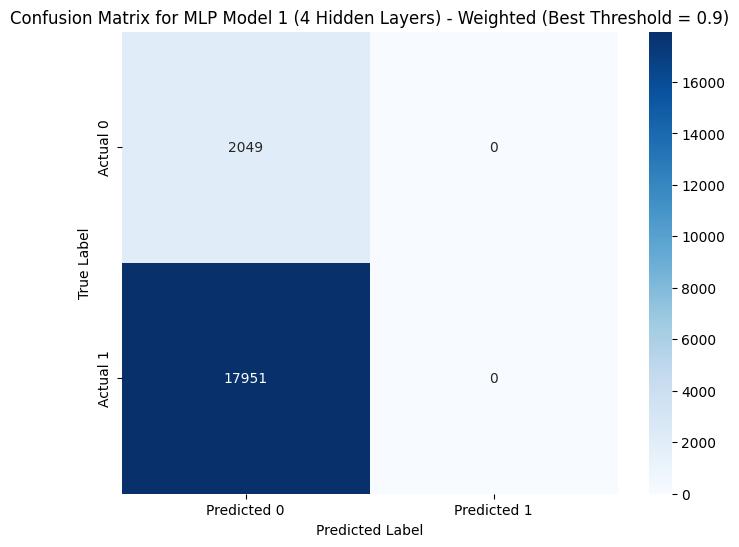

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# --- 4-Hidden Layer Model (Best Tuned Threshold) ---
model_name = f'MLP Model 1 (4 Hidden Layers) - Weighted (Best Threshold = {best_threshold_new_4_layer})'
y_pred = y_pred_best_threshold_new_4_layer

# Recalculate accuracy for this specific y_pred, as it was likely from the report
report = classification_report(y_test, y_pred, output_dict=True)
accuracy = report['accuracy']

print(f"--- Results for {model_name} ---")
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate F1-score for class 0
if '0' in report and isinstance(report['0'], dict):
    f1_0 = report['0'].get('f1-score', 0.0)
else:
    f1_0 = 0.0

print(f"F1 Score (Class 0): {f1_0:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

### Evaluation for 3-Hidden Layer Weighted MLP Model (Default Threshold = 0.5)

--- Results for MLP Model 1 (3 Hidden Layers) - Weighted (Default 0.5 Threshold) ---
Test Accuracy: 0.7380
F1 Score (Class 0): 0.4256


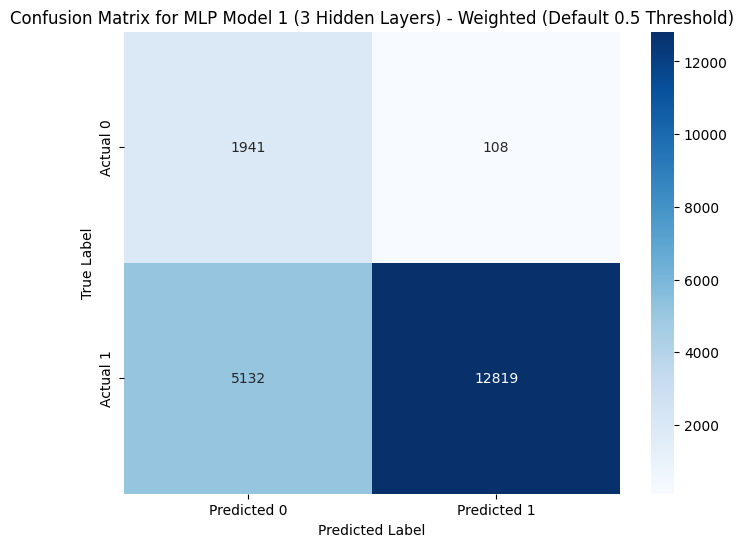

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# --- 3-Hidden Layer Model (Default 0.5 Threshold) ---
model_name = 'MLP Model 1 (3 Hidden Layers) - Weighted (Default 0.5 Threshold)'
y_pred = y_pred_3_model_1_custom_weighted
accuracy = accuracy_3_model_1_custom_weighted

print(f"--- Results for {model_name} ---")
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate F1-score for class 0
report = classification_report(y_test, y_pred, output_dict=True)
if '0' in report and isinstance(report['0'], dict):
    f1_0 = report['0'].get('f1-score', 0.0)
else:
    f1_0 = 0.0

print(f"F1 Score (Class 0): {f1_0:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

### Evaluation for 3-Hidden Layer Weighted MLP Model (Best Tuned Threshold)

--- Results for MLP Model 1 (3 Hidden Layers) - Weighted (Best Threshold = 0.45) ---
Test Accuracy: 0.8772
F1 Score (Class 0): 0.4760


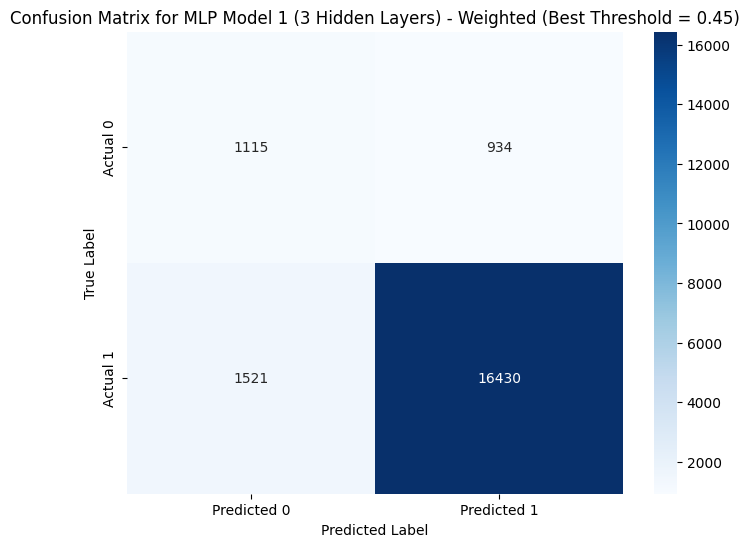

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# --- 3-Hidden Layer Model (Best Tuned Threshold) ---
model_name = f'MLP Model 1 (3 Hidden Layers) - Weighted (Best Threshold = {best_threshold})'
y_pred = y_pred_best_threshold

# Recalculate accuracy for this specific y_pred, as it was likely from the report
report = classification_report(y_test, y_pred, output_dict=True)
accuracy = report['accuracy']

print(f"--- Results for {model_name} ---")
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate F1-score for class 0
if '0' in report and isinstance(report['0'], dict):
    f1_0 = report['0'].get('f1-score', 0.0)
else:
    f1_0 = 0.0

print(f"F1 Score (Class 0): {f1_0:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

### Parameters for the Best 3-Hidden Layer Weighted MLP Model

In [39]:
print(params_3_layer_model_1_custom_weighted)

{'model__num_hidden_units_3': 16, 'model__num_hidden_units_2': 32, 'model__num_hidden_units_1': 64, 'model__num_hidden_layers': 3, 'model__momentum': 0.0, 'model__learning_rate': 0.001, 'model__l2_lambda': 0.0, 'model__dropout_rate': 0.1, 'epochs': 200, 'batch_size': 64}


In [9]:
all_models_results.append({
    'name': 'MLP Model 1 (3 Hidden Layers) - 200 Epochs, No L2, Dropout 0.1 (Weighted)',
    'y_pred': y_pred_3_model_1_custom_weighted,
    'accuracy': accuracy_3_model_1_custom_weighted
})

--- Displaying all 4 Confusion Matrices ---


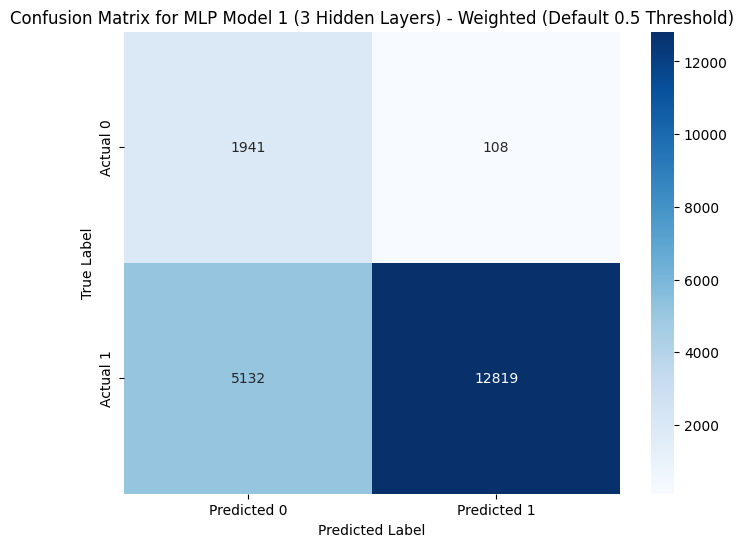

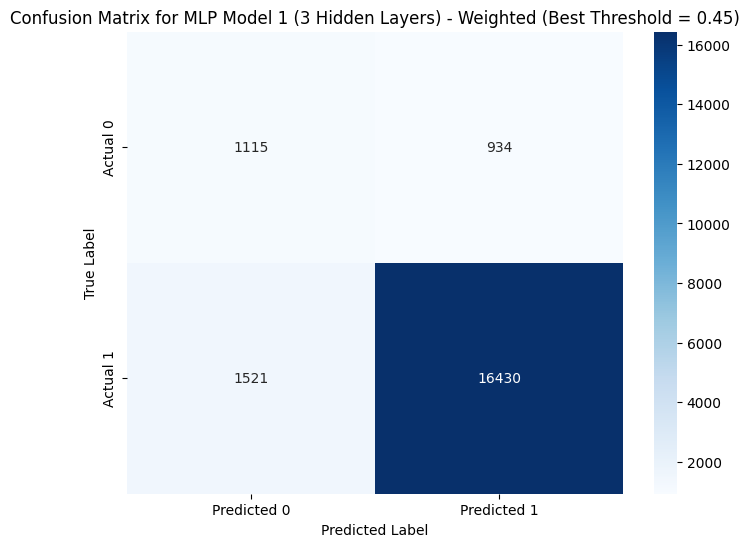

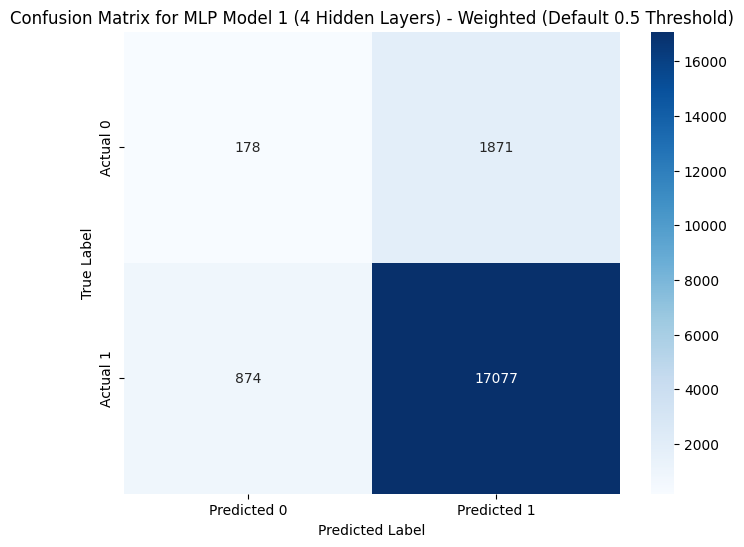

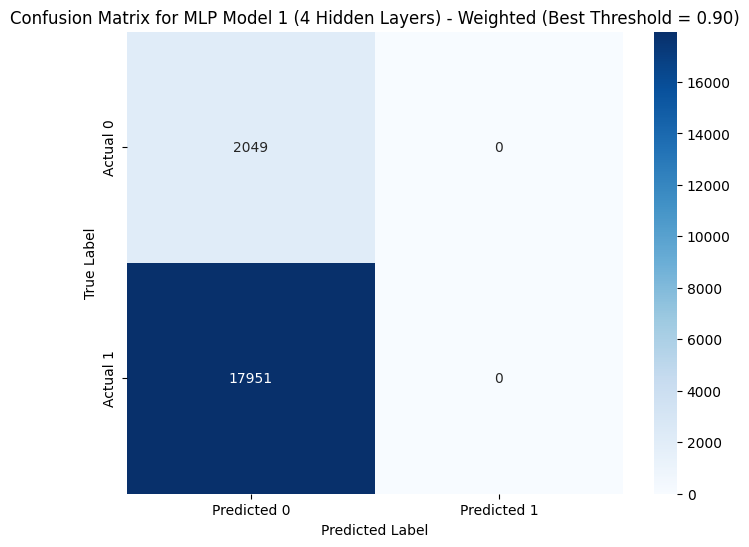

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("--- Displaying all 4 Confusion Matrices ---")

if not all_models_results:
    print("Warning: all_models_results is empty. Cannot display confusion matrices.")
else:
    for model_result in all_models_results:
        model_name = model_result['name']
        y_pred = model_result['y_pred']

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted 0', 'Predicted 1'],
                    yticklabels=['Actual 0', 'Actual 1'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix for {model_name}')
        plt.show()